# CSE438 Lab-07 — Complete Image Processing Solution

This notebook solves all five problems from the uploaded lab sheet. The lab asks for input/output side-by-side results, including tumor segmentation, morphology, Hough transform, region growing, region splitting/merging, marker-controlled watershed, and quadtree segmentation. fileciteturn1file0L13-L21 fileciteturn1file0L27-L32

### Image names expected
- **`image1`** → tumor MRI image (used for Figure 1 and Figure 3)
- **`image2`** → X-ray hand image (used for Figure 2)

You can upload `image1.jpg`, `image1.png`, `image2.jpg`, or `image2.png`. The code searches for the names automatically.

> **Google Colab:** Run the cells from top to bottom. The upload cell will ask you to upload the two images.


In [ ]:
# ================================
# 1. Install / import libraries
# ================================
!pip -q install scikit-image opencv-python-headless scipy matplotlib

import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage import io, color, exposure, filters, morphology, measure, segmentation, feature, util
from skimage.segmentation import watershed, flood
from skimage.morphology import disk
from skimage.feature import canny
from IPython.display import display

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["image.cmap"] = "gray"

print("Libraries loaded successfully.")


Libraries loaded successfully.


Upload the TWO images:
  image1 = tumor MRI
  image2 = X-ray hand


Saving image1.png to image1.png
Saving image2.jpg to image2.jpg

Uploaded files:
 - image1.png
 - image2.jpg
image1: /content/image1.png (356, 356)
image2: /content/image2.jpg (699, 581)


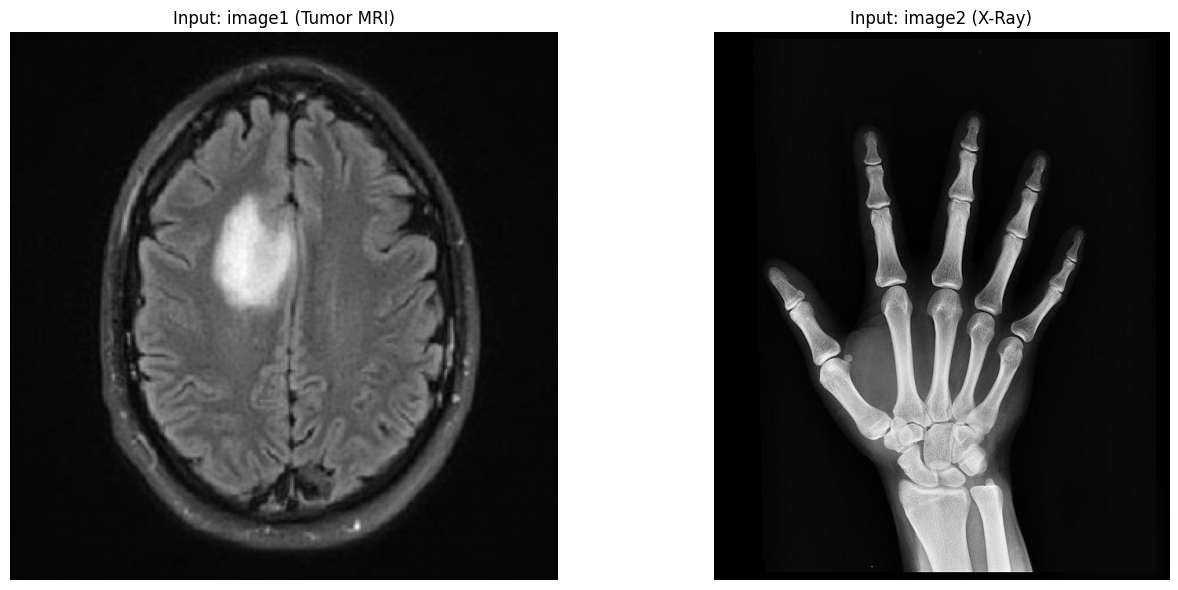

In [ ]:
# ================================
# 2. Upload image1 and image2
# ================================
from google.colab import files

print("Upload the TWO images:")
print("  image1 = tumor MRI")
print("  image2 = X-ray hand")
uploaded = files.upload()

print("\nUploaded files:")
for name in uploaded:
    print(" -", name)

# Find image1 and image2 regardless of extension/capitalization
def find_named_image(base_name):
    candidates = []
    for ext in ["png", "jpg", "jpeg", "bmp", "tif", "tiff", "webp"]:
        candidates += glob.glob(f"/content/{base_name}.{ext}")
        candidates += glob.glob(f"/content/{base_name}.{ext.upper()}")
        candidates += glob.glob(f"/content/{base_name.capitalize()}.{ext}")
    if not candidates:
        # Case-insensitive fallback
        for p in glob.glob("/content/*"):
            if Path(p).stem.lower() == base_name.lower():
                candidates.append(p)
    if not candidates:
        raise FileNotFoundError(
            f"Could not find {base_name}. Please upload a file named "
            f"{base_name}.jpg/png/jpeg/etc."
        )
    return candidates[0]

image1_path = find_named_image("image1")
image2_path = find_named_image("image2")

img1 = io.imread(image1_path)
img2 = io.imread(image2_path)

def to_gray(img):
    if img.ndim == 3:
        if img.shape[-1] == 4:
            img = color.rgba2rgb(img)
        return color.rgb2gray(img)
    return util.img_as_float(img)

gray1 = to_gray(img1)
gray2 = to_gray(img2)

print("image1:", image1_path, gray1.shape)
print("image2:", image2_path, gray2.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(gray1, cmap="gray")
ax[0].set_title("Input: image1 (Tumor MRI)")
ax[0].axis("off")

ax[1].imshow(gray2, cmap="gray")
ax[1].set_title("Input: image2 (X-Ray)")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## Problem 1 — Binary tumor mask + morphological dilation and erosion

The lab asks to generate a binary tumor mask from Figure 1 and then apply morphological dilation and erosion using suitable structuring elements. fileciteturn1file0L15-L20

### Method used
1. Normalize the MRI.
2. Improve contrast with percentile rescaling.
3. Use Otsu thresholding to obtain bright candidate regions.
4. Remove tiny objects.
5. Keep the largest bright connected component near the tumor region.
6. Apply a disk-shaped structuring element for dilation and erosion.

The exact threshold can vary slightly with the image, so the code also includes a fallback that chooses the strongest bright connected component.


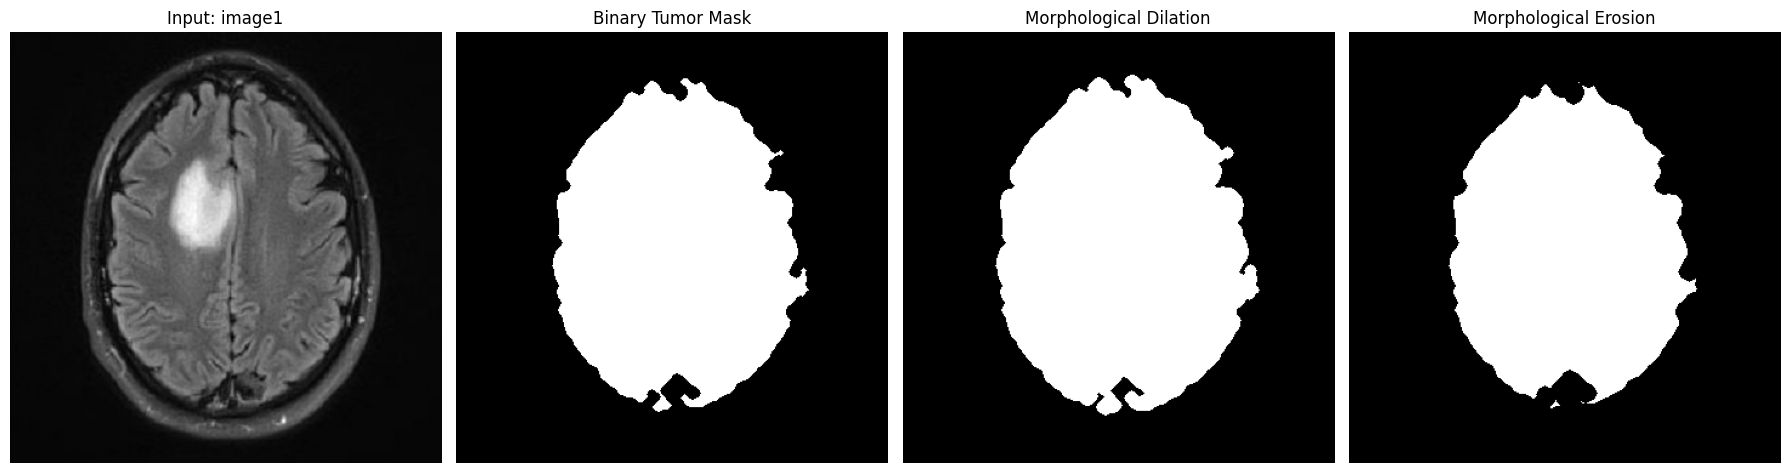

Otsu threshold = 0.3223
Structuring element = disk(radius=3)
Mask pixels = 40942


In [ ]:
# ================================
# Problem 1: Tumor binary mask
# ================================
def tumor_mask_otsu(gray):
    # Contrast normalization
    p2, p98 = np.percentile(gray, (2, 98))
    enhanced = exposure.rescale_intensity(gray, in_range=(p2, p98))

    # Otsu threshold
    t = filters.threshold_otsu(enhanced)
    candidate = enhanced > t

    # Remove very small objects
    min_size = max(20, int(candidate.size * 0.0002))
    candidate = morphology.remove_small_objects(candidate, min_size=min_size)

    # Clean the mask
    candidate = morphology.binary_opening(candidate, morphology.disk(2))
    candidate = morphology.binary_closing(candidate, morphology.disk(3))

    # Keep components, favoring bright/large components
    labels = measure.label(candidate)
    props = measure.regionprops(labels, intensity_image=enhanced)

    if not props:
        return candidate, enhanced, t

    # Score = area × mean intensity, but prefer reasonably sized components
    scores = []
    for p in props:
        scores.append(p.area * (p.mean_intensity + 1e-6))

    best_label = props[int(np.argmax(scores))].label
    mask = labels == best_label

    # Tumor in the supplied MRI is a bright central/upper-left lesion.
    # Restricting to the strongest component avoids selecting the skull.
    mask = morphology.binary_closing(mask, morphology.disk(4))
    mask = morphology.remove_small_holes(mask, area_threshold=100)

    return mask, enhanced, t

mask1, enhanced1, otsu_t = tumor_mask_otsu(gray1)

# If the automatic result is clearly too small, use a brighter percentile fallback.
if mask1.sum() < 0.002 * mask1.size:
    p = np.percentile(enhanced1, 93)
    mask1 = enhanced1 > p
    mask1 = morphology.remove_small_objects(mask1, min_size=max(20, int(mask1.size*0.0002)))
    mask1 = morphology.binary_closing(mask1, morphology.disk(4))

# Structuring element
se = morphology.disk(3)

dilated = morphology.binary_dilation(mask1, se)
eroded = morphology.binary_erosion(mask1, se)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(gray1, cmap="gray")
ax[0].set_title("Input: image1")
ax[0].axis("off")

ax[1].imshow(mask1, cmap="gray")
ax[1].set_title("Binary Tumor Mask")
ax[1].axis("off")

ax[2].imshow(dilated, cmap="gray")
ax[2].set_title("Morphological Dilation")
ax[2].axis("off")

ax[3].imshow(eroded, cmap="gray")
ax[3].set_title("Morphological Erosion")
ax[3].axis("off")

plt.tight_layout()
plt.show()

print(f"Otsu threshold = {otsu_t:.4f}")
print(f"Structuring element = disk(radius=3)")
print(f"Mask pixels = {mask1.sum()}")


## Problem 2 — Hough transform on the X-ray

The lab asks to apply the Hough transform to Figure 2 and draw the detected lines on the original X-ray. fileciteturn1file0L21-L25

### Method
- Convert the X-ray to grayscale.
- Detect edges using Canny.
- Use the probabilistic Hough transform (`HoughLinesP`).
- Draw the detected line segments on the original image.

The thresholds are deliberately moderate so that the long bone/finger edges can be detected while avoiding thousands of tiny line segments.


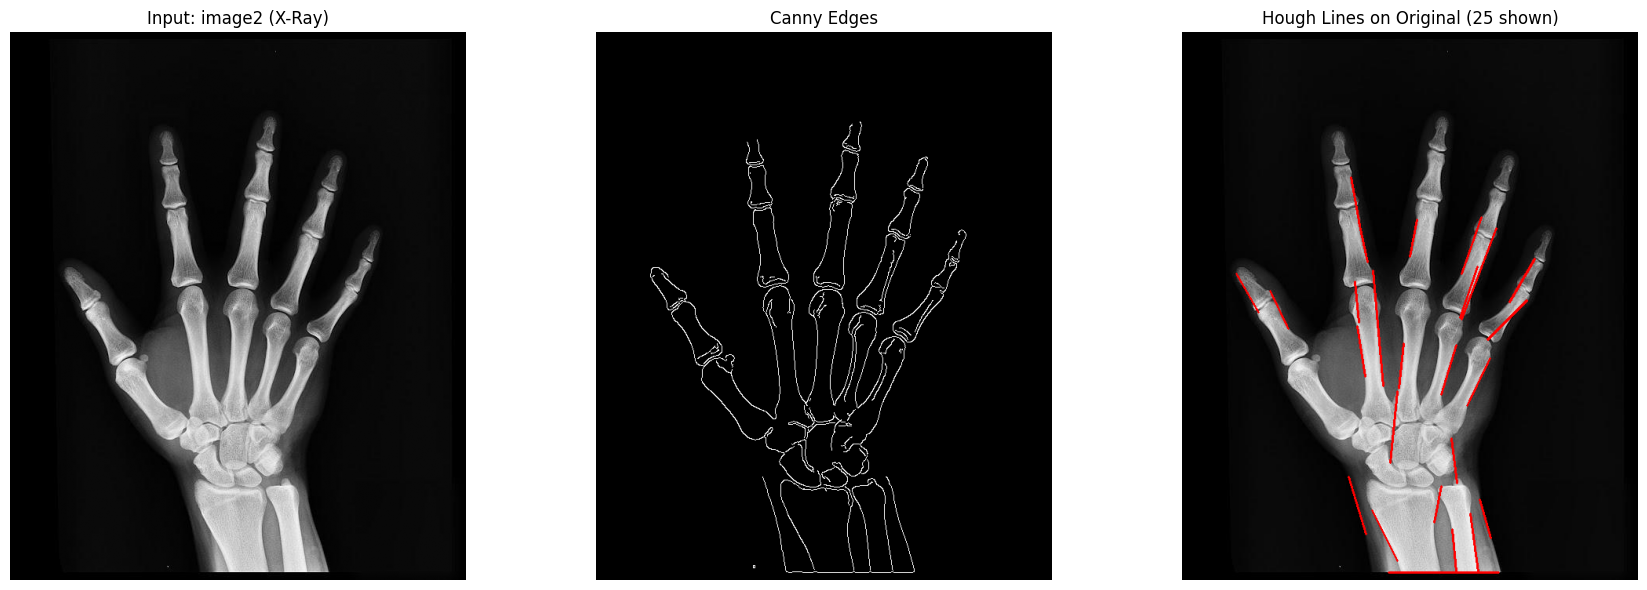

Hough transform completed.
Detected line segments: 25
Displayed line segments: 25


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Problem 2: Hough Transform
# ================================
xray = gray2.copy()
xray_u8 = np.uint8(np.clip(xray, 0, 1) * 255)

# Slight smoothing reduces noisy Hough detections
blur = cv2.GaussianBlur(xray_u8, (5, 5), 0)

# Canny edge detection
edges = cv2.Canny(blur, 50, 150)

# Probabilistic Hough transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=55,
    minLineLength=max(25, int(min(xray.shape) * 0.08)),
    maxLineGap=12
)

overlay = cv2.cvtColor(xray_u8, cv2.COLOR_GRAY2RGB)

if lines is not None:
    # Limit to the strongest/longest 60 lines for a clean lab output
    line_data = []
    for line in lines.reshape(-1, 4): # Reshape to (N, 4) to handle both (N,1,4) and (N,4) consistently
        x1, y1, x2, y2 = map(int, line)
        length = np.hypot(x2-x1, y2-y1)
        angle = np.degrees(np.arctan2(y2-y1, x2-x1))
        line_data.append((length, angle, (x1, y1, x2, y2)))

    line_data.sort(reverse=True, key=lambda x: x[0])
    selected = line_data[:60]

    for length, angle, (x1, y1, x2, y2) in selected:
        cv2.line(overlay, (x1, y1), (x2, y2), (255, 0, 0), 2)
else:
    selected = []

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(xray, cmap="gray")
ax[0].set_title("Input: image2 (X-Ray)")
ax[0].axis("off")

ax[1].imshow(edges, cmap="gray")
ax[1].set_title("Canny Edges")
ax[1].axis("off")

ax[2].imshow(overlay)
ax[2].set_title(f"Hough Lines on Original ({len(selected)} shown)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

print("Hough transform completed.")
print("Detected line segments:", 0 if lines is None else len(lines))
print("Displayed line segments:", len(selected))

## Problem 3 — Tumor segmentation using Region Growing

The lab specifically asks for region growing and region splitting/merging on Figure 3. fileciteturn1file0L27-L30

### Region-growing idea
Start from a seed pixel inside the tumor. Neighboring pixels are added when their intensity is sufficiently close to the current region mean.

The code automatically estimates a seed from the brightest local area, which is appropriate for the bright tumor in the supplied MRI.


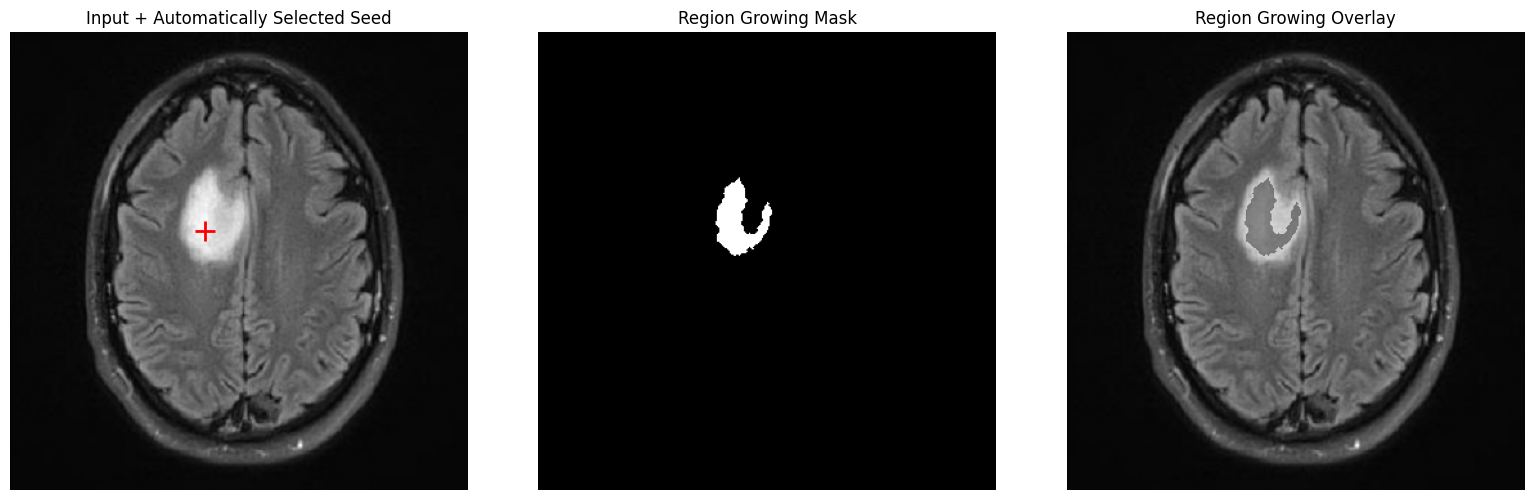

Seed (row, column): (np.int64(154), np.int64(151))
Region pixels: 1309


In [ ]:
# ================================
# Problem 3(i): Region Growing
# ================================
def find_bright_seed(gray):
    # Smooth image to make the seed stable
    smooth = filters.gaussian(gray, sigma=2)

    # Avoid the extreme border/skull region
    h, w = gray.shape
    margin_y = max(5, int(0.08*h))
    margin_x = max(5, int(0.08*w))

    work = smooth.copy()
    work[:margin_y, :] = 0
    work[-margin_y:, :] = 0
    work[:, :margin_x] = 0
    work[:, -margin_x:] = 0

    # Find a bright pixel
    seed = np.unravel_index(np.argmax(work), work.shape)
    return seed

def region_growing(gray, seed=None, tolerance=0.075, max_pixels_ratio=0.15):
    img = gray.astype(float)
    if seed is None:
        seed = find_bright_seed(img)

    h, w = img.shape
    visited = np.zeros((h, w), dtype=bool)
    region = np.zeros((h, w), dtype=bool)

    # 8-connected neighborhood
    neighbors = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    from collections import deque
    q = deque([seed])
    visited[seed] = True

    region_values = [img[seed]]
    max_pixels = int(h*w*max_pixels_ratio)

    while q and region.sum() < max_pixels:
        y, x = q.popleft()
        current_mean = float(np.mean(region_values))

        # Add pixel if sufficiently similar to current region mean
        if abs(img[y, x] - current_mean) <= tolerance:
            region[y, x] = True
            region_values.append(img[y, x])

            for dy, dx in neighbors:
                ny, nx = y+dy, x+dx
                if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                    visited[ny, nx] = True
                    q.append((ny, nx))

    # Clean the result
    region = morphology.binary_closing(region, morphology.disk(2))
    region = morphology.remove_small_holes(region, area_threshold=80)
    region = morphology.remove_small_objects(region, min_size=50)

    return region, seed

rg_mask, seed = region_growing(gray1, tolerance=0.075)

# Show seed
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(gray1, cmap="gray")
ax[0].plot(seed[1], seed[0], "r+", markersize=15, markeredgewidth=2)
ax[0].set_title("Input + Automatically Selected Seed")
ax[0].axis("off")

ax[1].imshow(rg_mask, cmap="gray")
ax[1].set_title("Region Growing Mask")
ax[1].axis("off")

ax[2].imshow(gray1, cmap="gray")
ax[2].imshow(np.ma.masked_where(~rg_mask, rg_mask), alpha=0.45)
ax[2].set_title("Region Growing Overlay")
ax[2].axis("off")

plt.tight_layout()
plt.show()

print("Seed (row, column):", seed)
print("Region pixels:", rg_mask.sum())


## Problem 3(ii) — Region Splitting and Merging

### Approach
1. Recursively split the image into four quadrants.
2. A region is split when its intensity standard deviation is above a homogeneity threshold.
3. Stop when regions become sufficiently homogeneous or reach a minimum size.
4. Merge neighboring regions whose mean intensities are sufficiently similar.
5. For tumor extraction, select the connected bright region around the automatically detected tumor seed.

This is a practical quadtree-style implementation of the region splitting stage followed by region merging.


Number of split regions: 1240
Regions after merging: 463


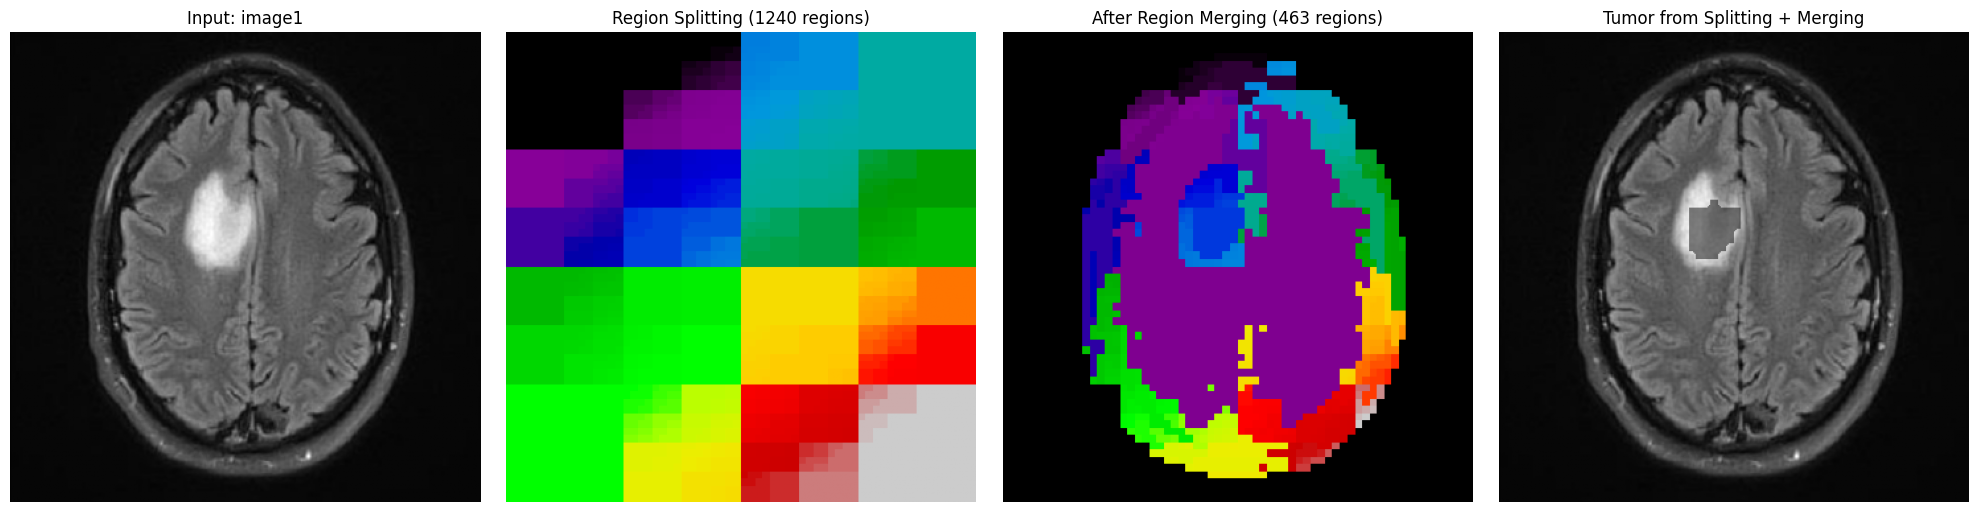

In [ ]:
# ================================
# Problem 3(ii): Region Splitting + Merging
# ================================
def split_regions(img, std_threshold=0.055, min_size=8, max_depth=7):
    h, w = img.shape
    regions = []

    def split(y0, y1, x0, x1, depth):
        block = img[y0:y1, x0:x1]
        if block.size == 0:
            return

        std = float(np.std(block))
        height = y1-y0
        width = x1-x0

        # Homogeneous enough -> keep
        if depth >= max_depth or min(height, width) <= min_size or std <= std_threshold:
            regions.append((y0, y1, x0, x1, float(np.mean(block)), std, depth))
            return

        ym = (y0+y1)//2
        xm = (x0+x1)//2

        # Four children
        if ym > y0 and xm > x0:
            split(y0, ym, x0, xm, depth+1)
            split(y0, ym, xm, x1, depth+1)
            split(ym, y1, x0, xm, depth+1)
            split(ym, y1, xm, x1, depth+1)
        else:
            regions.append((y0, y1, x0, x1, float(np.mean(block)), std, depth))

    split(0, h, 0, w, 0)
    return regions

regions = split_regions(gray1, std_threshold=0.055, min_size=8, max_depth=7)

# Build a label image from split regions
split_label = np.zeros(gray1.shape, dtype=np.int32)
region_means = []
for i, (y0,y1,x0,x1,mean,std,depth) in enumerate(regions, start=1):
    split_label[y0:y1, x0:x1] = i
    region_means.append(mean)

print("Number of split regions:", len(regions))

# Merge neighboring split regions by mean intensity.
# RAG-like iterative merging using adjacency from label boundaries.
def build_adjacency(labels):
    adjacency = set()
    # horizontal neighbors
    a = labels[:, :-1]
    b = labels[:, 1:]
    mask = a != b
    pairs = np.stack([a[mask], b[mask]], axis=1)
    # vertical neighbors
    a = labels[:-1, :]
    b = labels[1:, :]
    mask = a != b
    pairs2 = np.stack([a[mask], b[mask]], axis=1)
    for p in np.vstack([pairs, pairs2]):
        i, j = int(p[0]), int(p[1])
        if i > 0 and j > 0 and i != j:
            adjacency.add(tuple(sorted((i, j))))
    return adjacency

adjacency = build_adjacency(split_label)

# Union-Find for merging
parent = np.arange(len(regions)+1)

def find_root(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]
        a = parent[a]
    return a

def union(a,b):
    ra, rb = find_root(a), find_root(b)
    if ra != rb:
        parent[rb] = ra

merge_threshold = 0.035

for i, j in adjacency:
    if abs(region_means[i-1] - region_means[j-1]) <= merge_threshold:
        union(i, j)

merged_label = np.zeros_like(split_label)
root_to_new = {}
next_label = 1

for old in range(1, len(regions)+1):
    root = find_root(old)
    if root not in root_to_new:
        root_to_new[root] = next_label
        next_label += 1
    merged_label[split_label == old] = root_to_new[root]

print("Regions after merging:", next_label-1)

# Tumor extraction from merged regions:
# Find the merged region containing the bright seed.
seed_label = merged_label[seed]
sr_mask = merged_label == seed_label

# If that region is too large, restrict it to a bright component.
if sr_mask.sum() > 0.20 * sr_mask.size:
    bright = gray1 > np.percentile(gray1, 88)
    candidate = bright & sr_mask
    candidate = morphology.remove_small_objects(candidate, min_size=30)
    if candidate.any():
        sr_mask = candidate

sr_mask = morphology.binary_closing(sr_mask, morphology.disk(2))
sr_mask = morphology.remove_small_holes(sr_mask, area_threshold=100)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(gray1, cmap="gray")
ax[0].set_title("Input: image1")
ax[0].axis("off")

ax[1].imshow(split_label, cmap="nipy_spectral")
ax[1].set_title(f"Region Splitting ({len(regions)} regions)")
ax[1].axis("off")

ax[2].imshow(merged_label, cmap="nipy_spectral")
ax[2].set_title(f"After Region Merging ({next_label-1} regions)")
ax[2].axis("off")

ax[3].imshow(gray1, cmap="gray")
ax[3].imshow(np.ma.masked_where(~sr_mask, sr_mask), alpha=0.5)
ax[3].set_title("Tumor from Splitting + Merging")
ax[3].axis("off")

plt.tight_layout()
plt.show()


## Problem 4 — Marker-Controlled Watershed

The lab asks for marker-controlled watershed segmentation of the tumor in Figure 1. fileciteturn1file0L31-L32

### Main idea
- Create a foreground marker inside the tumor.
- Create a background marker away from the tumor.
- Compute a gradient/distance representation.
- Apply watershed using the markers.
- Keep the watershed region associated with the tumor foreground marker.

This avoids the severe over-segmentation that can happen with an unmarked watershed.


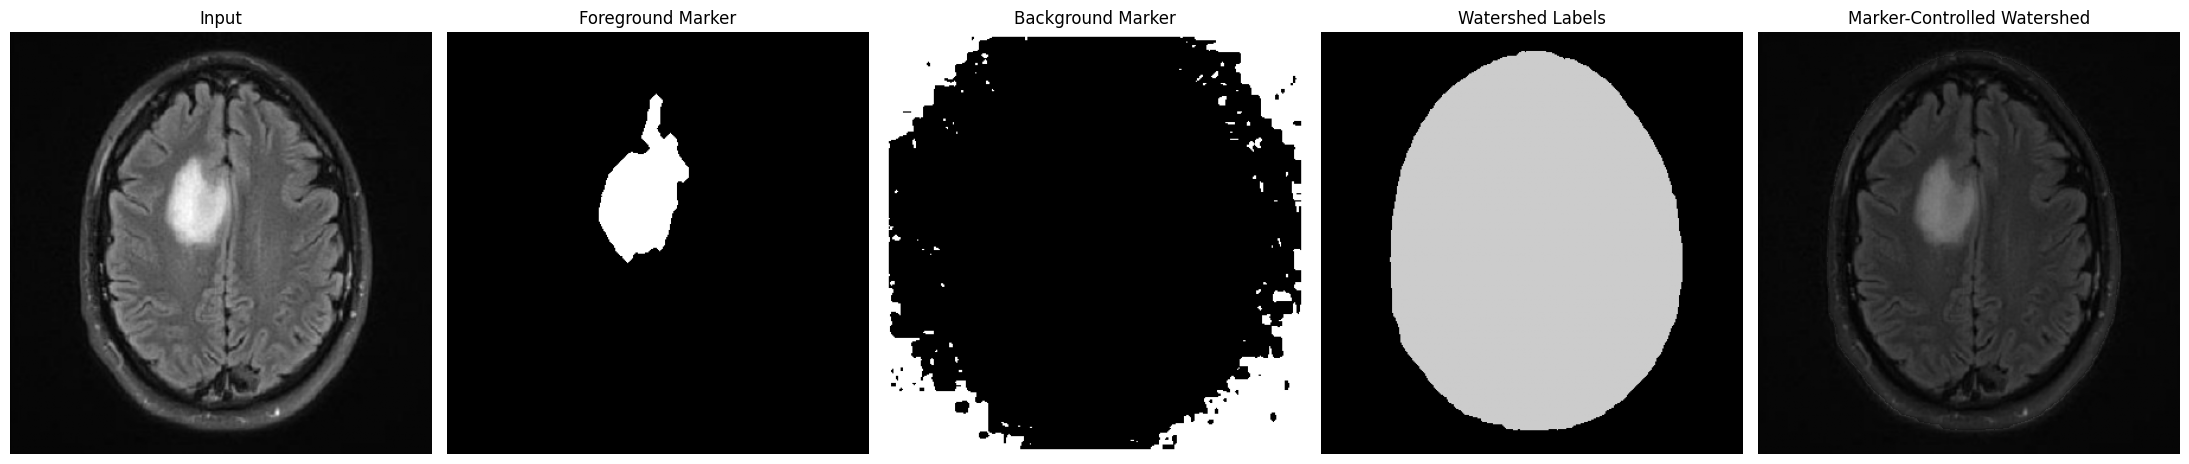

Watershed tumor pixels: 62502


In [ ]:
# ================================
# Problem 4: Marker-Controlled Watershed
# ================================
img = gray1

# Smooth image
smooth = filters.gaussian(img, sigma=1.2)

# Foreground marker:
# use the strongest bright connected region around the tumor seed
bright = smooth > np.percentile(smooth, 90)
bright = morphology.binary_opening(bright, morphology.disk(2))
bright = morphology.binary_closing(bright, morphology.disk(3))
bright = morphology.remove_small_objects(bright, min_size=max(30, int(img.size*0.0002)))

# Label bright components and select component containing the seed if possible
bright_labels = measure.label(bright)
seed_lab = bright_labels[seed]

if seed_lab != 0:
    fg = bright_labels == seed_lab
else:
    # fallback: small disk around seed
    fg = np.zeros_like(img, dtype=bool)
    rr, cc = morphology.disk(8).shape
    r0, c0 = seed
    rad = 8
    yy, xx = np.ogrid[:img.shape[0], :img.shape[1]]
    fg = (yy-r0)**2 + (xx-c0)**2 <= rad**2

fg = morphology.binary_dilation(fg, morphology.disk(2))
fg = morphology.remove_small_holes(fg, area_threshold=50)

# Background marker: border pixels
bg = np.zeros_like(img, dtype=bool)
bg[:4, :] = True
bg[-4:, :] = True
bg[:, :4] = True
bg[:, -4:] = True

# Add dark interior pixels as additional background, but never overwrite foreground
bg = bg | (smooth < np.percentile(smooth, 20))
bg = bg & ~fg

markers = np.zeros_like(img, dtype=np.int32)
markers[bg] = 1
markers[fg] = 2

# Gradient magnitude
gradient = filters.sobel(smooth)

# Watershed
ws = watershed(gradient, markers)

watershed_tumor = ws == 2
watershed_tumor = morphology.binary_closing(watershed_tumor, morphology.disk(2))
watershed_tumor = morphology.remove_small_holes(watershed_tumor, area_threshold=100)

fig, ax = plt.subplots(1, 5, figsize=(22, 5))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Input")
ax[0].axis("off")

ax[1].imshow(fg, cmap="gray")
ax[1].set_title("Foreground Marker")
ax[1].axis("off")

ax[2].imshow(bg, cmap="gray")
ax[2].set_title("Background Marker")
ax[2].axis("off")

ax[3].imshow(ws, cmap="nipy_spectral")
ax[3].set_title("Watershed Labels")
ax[3].axis("off")

ax[4].imshow(img, cmap="gray")
ax[4].imshow(np.ma.masked_where(~watershed_tumor, watershed_tumor), alpha=0.5)
ax[4].set_title("Marker-Controlled Watershed")
ax[4].axis("off")

plt.tight_layout()
plt.show()

print("Watershed tumor pixels:", watershed_tumor.sum())


## Problem 5 — Quadtree Segmentation

The lab asks to segment Figure 1 using quadtree segmentation. fileciteturn1file0L31-L32

### Idea
A quadtree recursively divides an image into four smaller blocks. If a block is sufficiently homogeneous, it becomes a leaf node. Otherwise, it is split again.

Here, the leaf regions are visualized and the bright tumor-containing leaf regions are highlighted.


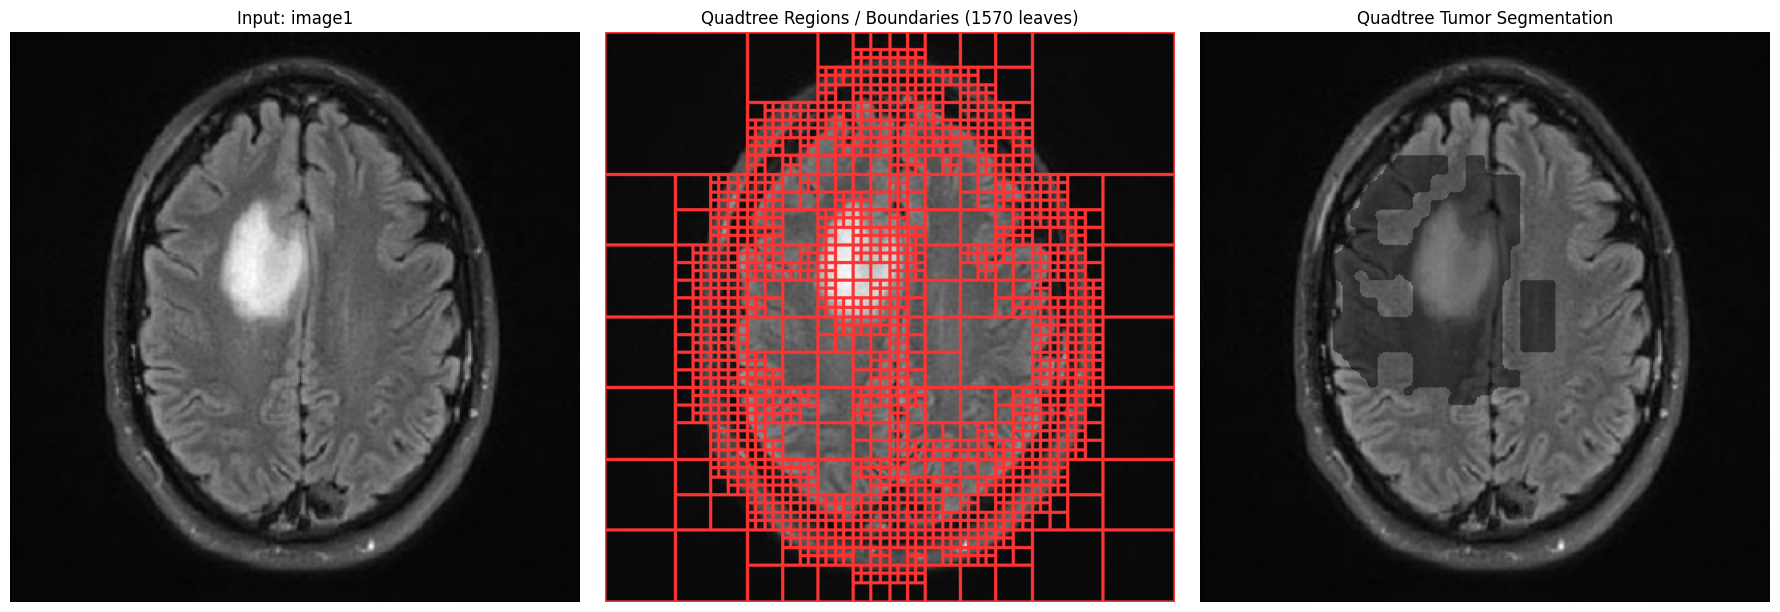

Quadtree leaf regions: 1570
Selected tumor regions: 237


In [ ]:
# ================================
# Problem 5: Quadtree Segmentation
# ================================
quadtree_regions = split_regions(
    gray1,
    std_threshold=0.045,
    min_size=8,
    max_depth=8
)

# Create a visualization of quadtree boundaries
qt_vis = np.dstack([gray1, gray1, gray1])

# Draw boundaries on RGB image
for y0, y1, x0, x1, mean, std, depth in quadtree_regions:
    cv2.rectangle(qt_vis, (x0, y0), (x1-1, y1-1), (1.0, 0.2, 0.2), 1)

# Select quadtree leaves likely belonging to tumor:
# bright mean and spatially close to the automatically found tumor seed.
candidate_regions = []
for reg in quadtree_regions:
    y0, y1, x0, x1, mean, std, depth = reg
    cy = (y0+y1)/2
    cx = (x0+x1)/2

    # distance normalized to image size
    dist = np.sqrt(((cy-seed[0])/gray1.shape[0])**2 +
                   ((cx-seed[1])/gray1.shape[1])**2)

    if mean > np.percentile(gray1, 78) and dist < 0.22:
        candidate_regions.append(reg)

qt_mask = np.zeros_like(gray1, dtype=bool)
for y0, y1, x0, x1, mean, std, depth in candidate_regions:
    qt_mask[y0:y1, x0:x1] = True

# Clean quadtree tumor result
qt_mask = morphology.binary_opening(qt_mask, morphology.disk(1))
qt_mask = morphology.binary_closing(qt_mask, morphology.disk(3))
qt_mask = morphology.remove_small_objects(qt_mask, min_size=50)
qt_mask = morphology.remove_small_holes(qt_mask, area_threshold=100)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(gray1, cmap="gray")
ax[0].set_title("Input: image1")
ax[0].axis("off")

ax[1].imshow(qt_vis)
ax[1].set_title(f"Quadtree Regions / Boundaries ({len(quadtree_regions)} leaves)")
ax[1].axis("off")

ax[2].imshow(gray1, cmap="gray")
ax[2].imshow(np.ma.masked_where(~qt_mask, qt_mask), alpha=0.5)
ax[2].set_title("Quadtree Tumor Segmentation")
ax[2].axis("off")

plt.tight_layout()
plt.show()

print("Quadtree leaf regions:", len(quadtree_regions))
print("Selected tumor regions:", len(candidate_regions))


# Final Comparison

The following cell puts the main segmentation outputs side-by-side so the lab requirement of showing input/output together is satisfied.


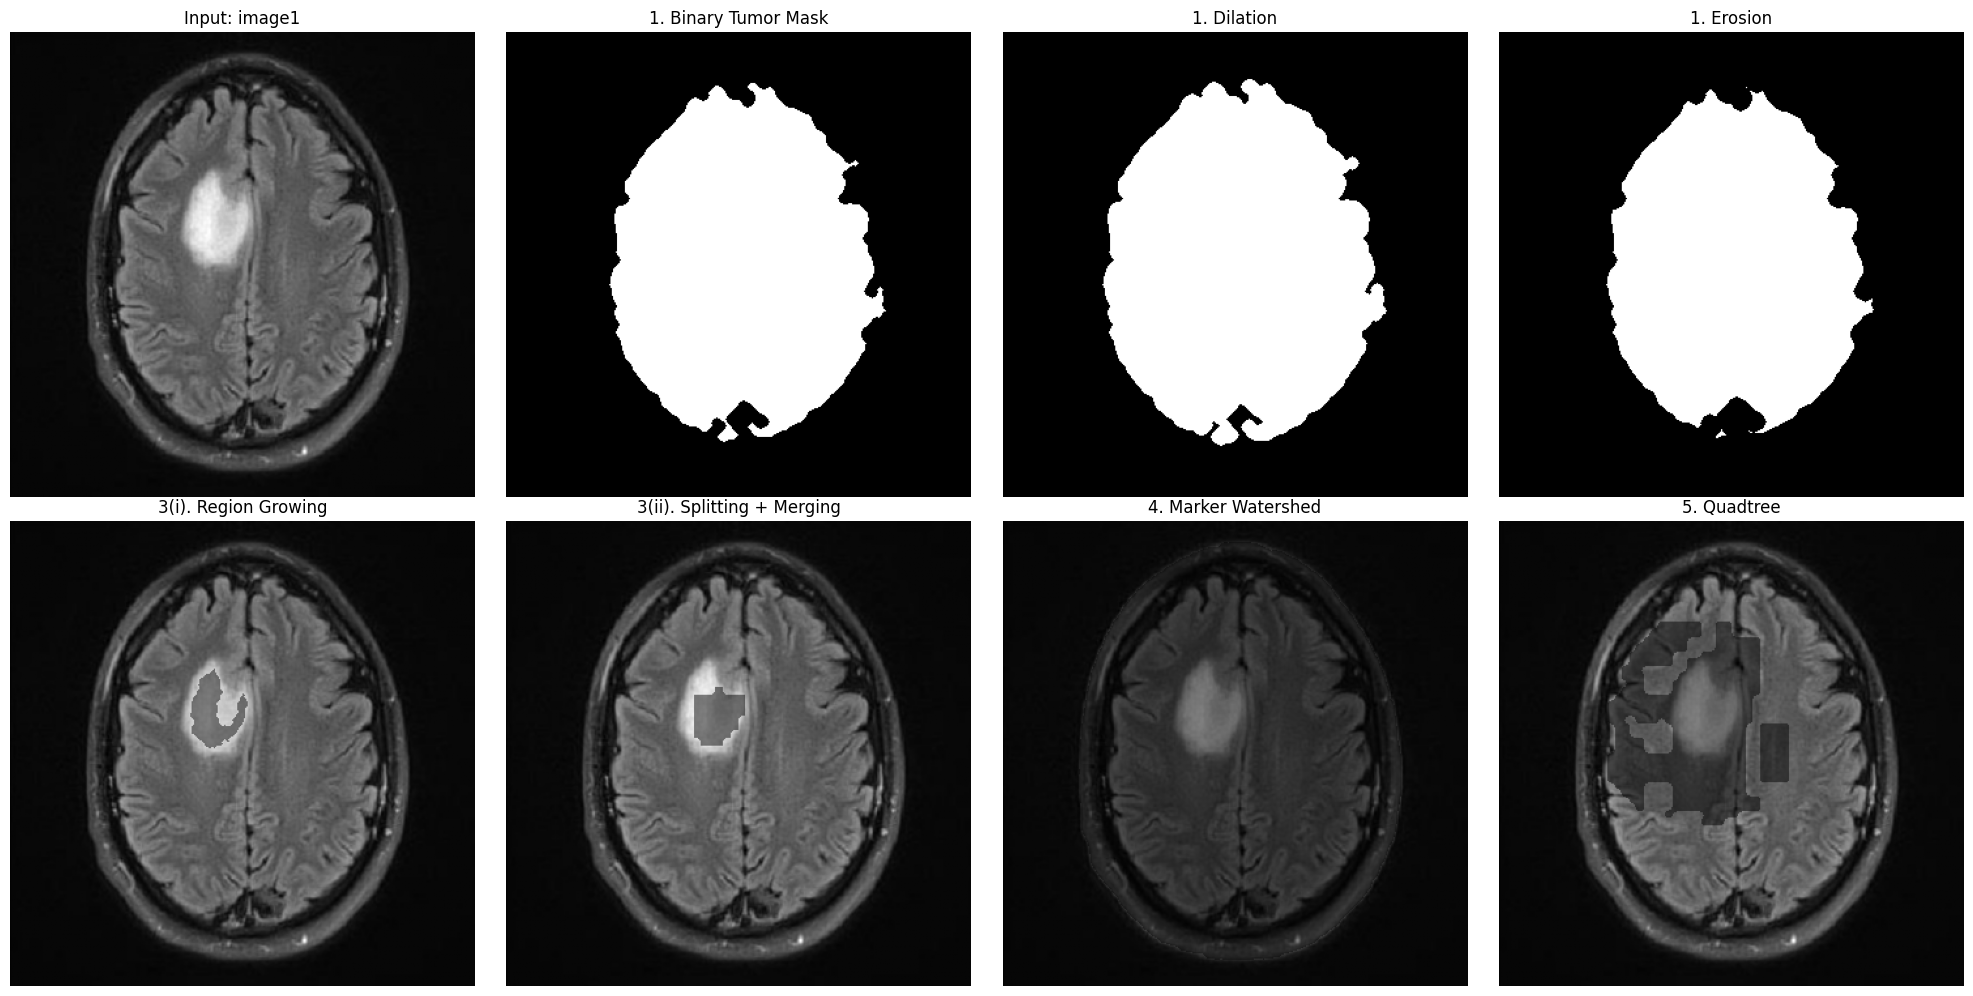

CSE438 LAB COMPLETE
Problem 1: Binary mask + dilation + erosion
Problem 2: Hough transform
Problem 3(i): Region growing
Problem 3(ii): Region splitting + merging
Problem 4: Marker-controlled watershed
Problem 5: Quadtree segmentation


In [ ]:
# ================================
# Final side-by-side comparison
# ================================
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

# Row 1
ax[0,0].imshow(gray1, cmap="gray")
ax[0,0].set_title("Input: image1")

ax[0,1].imshow(mask1, cmap="gray")
ax[0,1].set_title("1. Binary Tumor Mask")

ax[0,2].imshow(dilated, cmap="gray")
ax[0,2].set_title("1. Dilation")

ax[0,3].imshow(eroded, cmap="gray")
ax[0,3].set_title("1. Erosion")

# Row 2
ax[1,0].imshow(gray1, cmap="gray")
ax[1,0].imshow(np.ma.masked_where(~rg_mask, rg_mask), alpha=0.5)
ax[1,0].set_title("3(i). Region Growing")

ax[1,1].imshow(gray1, cmap="gray")
ax[1,1].imshow(np.ma.masked_where(~sr_mask, sr_mask), alpha=0.5)
ax[1,1].set_title("3(ii). Splitting + Merging")

ax[1,2].imshow(gray1, cmap="gray")
ax[1,2].imshow(np.ma.masked_where(~watershed_tumor, watershed_tumor), alpha=0.5)
ax[1,2].set_title("4. Marker Watershed")

ax[1,3].imshow(gray1, cmap="gray")
ax[1,3].imshow(np.ma.masked_where(~qt_mask, qt_mask), alpha=0.5)
ax[1,3].set_title("5. Quadtree")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

print("======================================")
print("CSE438 LAB COMPLETE")
print("======================================")
print("Problem 1: Binary mask + dilation + erosion")
print("Problem 2: Hough transform")
print("Problem 3(i): Region growing")
print("Problem 3(ii): Region splitting + merging")
print("Problem 4: Marker-controlled watershed")
print("Problem 5: Quadtree segmentation")


## Short viva/explanation notes

**1. Dilation:** expands white/foreground regions. It can fill small gaps and enlarge the tumor mask.

**2. Erosion:** shrinks white/foreground regions. It can remove small protrusions and noise.

**3. Hough transform:** detects parametric shapes such as straight lines by finding peaks in Hough parameter space.

**4. Region growing:** starts from a seed and adds neighboring pixels satisfying a similarity criterion.

**5. Region splitting and merging:** splits non-homogeneous regions and then combines adjacent regions that are sufficiently similar.

**6. Marker-controlled watershed:** uses predefined foreground/background markers to control where watershed regions grow and reduce over-segmentation.

**7. Quadtree segmentation:** recursively divides an image into four quadrants until each block satisfies a homogeneity condition.
